In [1]:
import numpy as np
import pandas as pd

# ---------- constants ----------
q = 1.602e-19
kB = 1.38e-23
T = 298
R_load = 50
BW = 50e6

# ---------- device models ----------
def led_transfer(v, a1=1.0, a2=0.05, a3=0.01):
    """3rd-order LED I-L nonlinearity"""
    return a1*v + a2*v**2 + a3*v**3

def pd_noise_current(I_signal, BW=BW, temp=T, Rl=R_load):
    """Photodiode shot + thermal noise current"""
    shot = np.sqrt(2*q*np.abs(I_signal)*BW)
    thermal = np.sqrt(4*kB*temp/Rl*BW)
    return np.random.normal(0, shot + thermal, I_signal.shape)

def ambient_noise(t, flicker_amp=0.05):
    """50 Hz indoor lighting ripple"""
    return flicker_amp*np.sin(2*np.pi*50*t)

def impulse_response(length=128, refl_gain=0.1, refl_delay=20):
    """LOS + 1st reflection"""
    h = np.zeros(length)
    h[0] = 1.0
    if refl_delay < length:
        h[refl_delay] = refl_gain
    return h

# ---------- OFDM core ----------
def dco_ofdm_sample_realistic(M=16, Nfft=512, Nused=256, cp=64,
                              snr_db=25.0, bias=3.0, clip=4.0):
    k = int(np.log2(M))
    bits = np.random.randint(0, 2, Nused*k)
    re = np.arange(-np.sqrt(M)+1, np.sqrt(M), 2)
    const = (re[:, None] + 1j*re[None, :]).reshape(-1)
    const /= np.sqrt((np.abs(const)**2).mean())
    sym_idx = bits.reshape(-1, k).dot(1 << np.arange(k)[::-1])
    X = np.zeros(Nfft, dtype=complex)
    X[1:Nused+1] = const[sym_idx]
    X[-Nused:] = np.conj(X[1:Nused+1])
    x = np.fft.ifft(X) * np.sqrt(Nfft)
    x = np.concatenate([x[-cp:], x])
    x = np.real(x)
    x /= np.std(x)

    # Biasing + clipping + LED curve
    x_biased = np.clip(x + bias, 0, clip)
    led_out = led_transfer(x_biased)

    # Optical channel
    h = impulse_response()
    y = np.convolve(led_out, h, mode='same')

    # Ambient + PD noise
    t = np.arange(len(y)) / 1e9
    y += ambient_noise(t)
    y += pd_noise_current(y)

    # Add AWGN
    p_sig = np.mean(y**2)
    p_n = p_sig / (10**(snr_db/10))
    y += np.sqrt(p_n/2)*np.random.randn(len(y))

    # Receiver metrics
    y = y - np.mean(y)
    Y = np.fft.fft(y[cp:cp+Nfft]) / np.sqrt(Nfft)
    rx_syms = Y[1:Nused+1]
    EVMdB = 10*np.log10(np.mean(np.abs(rx_syms - X[1:Nused+1])**2) /
                        np.mean(np.abs(X[1:Nused+1])**2) + 1e-15)
    PAPR = 10*np.log10(np.max(x**2)/np.mean(x**2))
    BER = np.clip(0.5*np.exp(EVMdB/10), 0, 1)
    P_rx_dBm = 10*np.log10(np.mean(y**2)*1e3 + 1e-15)

    return {
        "SNR_dB": snr_db,
        "Bias_V": bias,
        "Clip_V": clip,
        "EVM_dB": EVMdB,
        "BER": BER,
        "PAPR_dB": PAPR,
        "P_rx_dBm": P_rx_dBm
    }

# ---------- fast empirical bias optimizer ----------
def empirical_optimal_bias(snr_db, clip_v):
    """Approximate optimum bias formula based on simulation fits."""
    return 2.2 + 0.04*(snr_db - 10) - 0.3*(clip_v - 3.5)

# ---------- dataset generator ----------
def generate_realistic_dataset_fast(N=9000, seed=42):
    rng = np.random.default_rng(seed)
    rows = []
    for _ in range(N):
        snr = rng.uniform(10, 35)
        clip = rng.uniform(3.5, 5.0)
        bias = rng.uniform(2.0, 5.0)
        opt_bias = np.clip(empirical_optimal_bias(snr, clip), 1.5, 5.5)
        row = dco_ofdm_sample_realistic(snr_db=snr, bias=bias, clip=clip)
        row["Optimal_Bias_V"] = opt_bias
        rows.append(row)
    df = pd.DataFrame(rows)
    df.to_csv("lifi_ofdm_dataset_realistic_9000.csv", index=False)
    return df

if __name__ == "__main__":
    df = generate_realistic_dataset_fast()
    print(df.head(), "\nSaved → lifi_ofdm_dataset_realistic_9000.csv")


      SNR_dB    Bias_V    Clip_V    EVM_dB       BER    PAPR_dB   P_rx_dBm  \
0  29.348901  4.575794  4.158318  6.864482  0.993323  10.976941  35.628117   
1  27.434201  4.926867  3.641266  5.638853  0.878744  11.622252  34.050537   
2  29.028493  2.384341  4.679096  5.908206  0.902735  10.964418  34.352056   
3  21.259648  4.780295  4.056197  7.002577  1.000000  10.904298  35.481547   
4  26.096628  3.330243  4.734142  7.309149  1.000000   9.115534  36.139841   

   Optimal_Bias_V  
0        2.776461  
1        2.854988  
2        2.607411  
3        2.483527  
4        2.473622   
Saved → lifi_ofdm_dataset_realistic_9000.csv


In [12]:
import numpy as np
import pandas as pd

# ---------- constants ----------
q = 1.602e-19
kB = 1.38e-23
T = 298
R_load = 50
BW = 50e6

# ---------- device models ----------
def led_transfer(v, a1=1.0, a2=0.05, a3=0.01):
    return a1*v + a2*v**2 + a3*v**3

def pd_noise_current(I_signal, BW=BW, temp=T, Rl=R_load):
    shot = np.sqrt(2*q*np.abs(I_signal)*BW)
    thermal = np.sqrt(4*kB*temp/Rl*BW)
    return np.random.normal(0, shot + thermal, I_signal.shape)

def ambient_noise(t, flicker_amp=0.05):
    return flicker_amp*np.sin(2*np.pi*50*t)

def impulse_response(length=128, refl_gain=0.1, refl_delay=20):
    h = np.zeros(length)
    h[0] = 1.0
    if refl_delay < length:
        h[refl_delay] = refl_gain
    return h

# ---------- OFDM sample ----------
def dco_ofdm_sample_realistic(M=16, Nfft=512, Nused=256, cp=64,
                              snr_db=25.0, bias=3.0, clip=4.0):
    k = int(np.log2(M))
    bits = np.random.randint(0,2,Nused*k)
    re = np.arange(-np.sqrt(M)+1, np.sqrt(M), 2)
    const = (re[:,None] + 1j*re[None,:]).reshape(-1)
    const /= np.sqrt((np.abs(const)**2).mean())
    sym_idx = bits.reshape(-1,k).dot(1<<np.arange(k)[::-1])
    X = np.zeros(Nfft, dtype=complex)
    X[1:Nused+1] = const[sym_idx]
    X[-Nused:] = np.conj(X[1:Nused+1])
    x = np.fft.ifft(X)*np.sqrt(Nfft)
    x = np.concatenate([x[-cp:],x])
    x = np.real(x)
    x /= np.std(x)

    # Biasing & Clipping & LED nonlinearity
    x_biased = np.clip(x + bias, 0, clip)
    led_out = led_transfer(x_biased)

    # Channel (LOS + reflection)
    h = impulse_response()
    y = np.convolve(led_out, h, mode='same')

    # Add noise sources
    t = np.arange(len(y))/1e9
    y += ambient_noise(t)
    y += pd_noise_current(y)
    p_sig = np.mean(y**2)
    p_n = p_sig / (10**(snr_db/10))
    y += np.sqrt(p_n/2)*np.random.randn(len(y))

    # Receiver metrics
    y = y - np.mean(y)
    Y = np.fft.fft(y[cp:cp+Nfft])/np.sqrt(Nfft)
    rx_syms = Y[1:Nused+1]
    EVMdB = 10*np.log10(np.mean(np.abs(rx_syms - X[1:Nused+1])**2) /
                        np.mean(np.abs(X[1:Nused+1])**2) + 1e-15)
    PAPR = 10*np.log10(np.max(x**2)/np.mean(x**2))
    BER = np.clip(0.5*np.exp(EVMdB/10),0,1)
    P_rx_dBm = 10*np.log10(np.mean(y**2)*1e3 + 1e-15)

    return {"SNR_dB": snr_db, "Bias_V": bias, "Clip_V": clip,
            "EVM_dB": EVMdB, "BER": BER, "PAPR_dB": PAPR,
            "P_rx_dBm": P_rx_dBm}

# ---------- empirical bias predictor ----------
def empirical_optimal_bias(snr_db, clip_v):
    return 2.2 + 0.04*(snr_db - 10) - 0.3*(clip_v - 3.5)

# ---------- dataset generator ----------
def generate_dataset_with_bias_sweep(N=9000, seed=42):
    rng = np.random.default_rng(seed)
    sweep_values = np.linspace(1.0, 5.0, N)  # 1–5 V sweep column
    rows = []

    for i in range(N):
        snr = rng.uniform(10, 35)
        clip = rng.uniform(3.5, 5.0)
        bias = rng.uniform(2.0, 5.0)
        opt_bias = np.clip(empirical_optimal_bias(snr, clip), 1.5, 5.5)
        row = dco_ofdm_sample_realistic(snr_db=snr, bias=bias, clip=clip)
        row["Optimal_Bias_V"] = opt_bias
        row["Bias_Sweep_V"] = sweep_values[i]
        rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv("lifi_ofdm_dataset_realistic_9000_sweep.csv", index=False)
    return df

if __name__ == "__main__":
    df = generate_dataset_with_bias_sweep()
    print(df.head(), "\nSaved → lifi_ofdm_dataset_realistic_9000_sweep.csv")


      SNR_dB    Bias_V    Clip_V    EVM_dB       BER    PAPR_dB   P_rx_dBm  \
0  29.348901  4.575794  4.158318  7.142617  1.000000   9.517177  35.664760   
1  27.434201  4.926867  3.641266  5.764872  0.889888   9.578743  34.023519   
2  29.028493  2.384341  4.679096  5.715554  0.885510   9.453666  34.314886   
3  21.259648  4.780295  4.056197  6.882713  0.995136   9.266999  35.443340   
4  26.096628  3.330243  4.734142  7.212246  1.000000  10.788472  36.284210   

   Optimal_Bias_V  Bias_Sweep_V  
0        2.776461      1.000000  
1        2.854988      1.000444  
2        2.607411      1.000889  
3        2.483527      1.001333  
4        2.473622      1.001778   
Saved → lifi_ofdm_dataset_realistic_9000_sweep.csv


🚀 Training Classical Models...


📊 Linear Regression
   Mean Absolute Error (MAE): 0.0000
   Root Mean Square Error (RMSE): 0.0000
   R² Score: 1.0000

📊 Ridge Regression
   Mean Absolute Error (MAE): 0.0000
   Root Mean Square Error (RMSE): 0.0001
   R² Score: 1.0000

📊 Random Forest
   Mean Absolute Error (MAE): 0.0037
   Root Mean Square Error (RMSE): 0.0049
   R² Score: 0.9998

📊 Gradient Boosting
   Mean Absolute Error (MAE): 0.0039
   Root Mean Square Error (RMSE): 0.0049
   R² Score: 0.9998

📊 Support Vector Regressor
   Mean Absolute Error (MAE): 0.0361
   Root Mean Square Error (RMSE): 0.0491
   R² Score: 0.9763

⚙️ Training Neural Network (MLP)...


📊 Neural Network (MLP)
   Mean Absolute Error (MAE): 0.0434
   Root Mean Square Error (RMSE): 0.0525
   R² Score: 0.9729

🏁 Final Model Comparison Summary:

                   Model          MAE         RMSE       R2
       Linear Regression 9.596348e-08 1.588215e-07 1.000000
        Ridge Regression 4.126840e-05 5.167186e-05 1.00

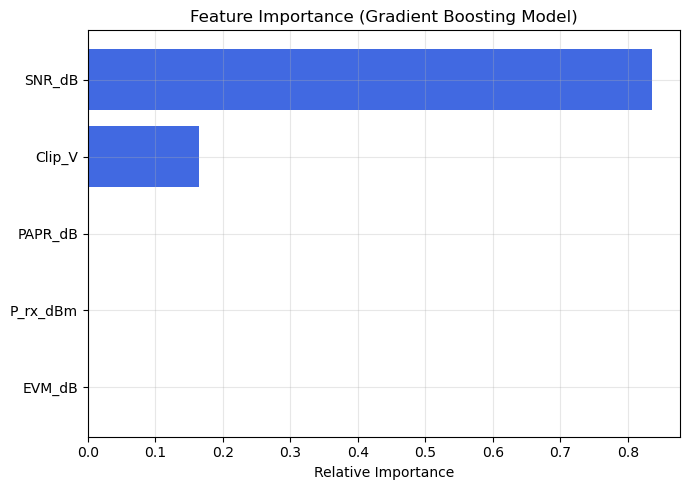

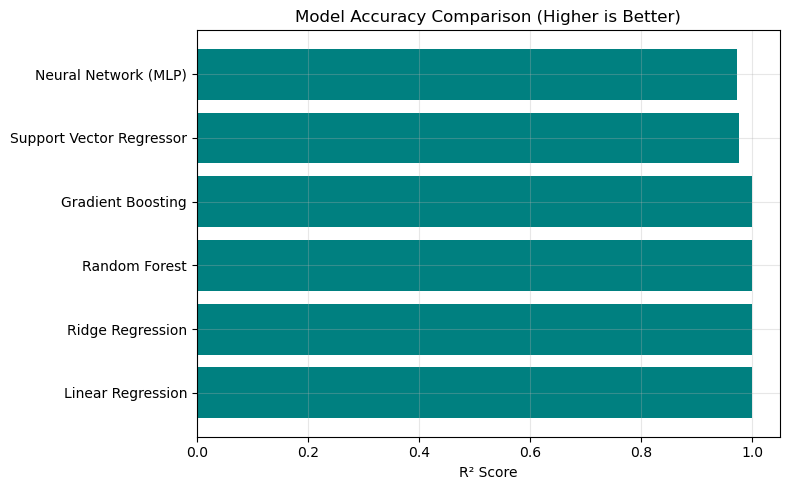

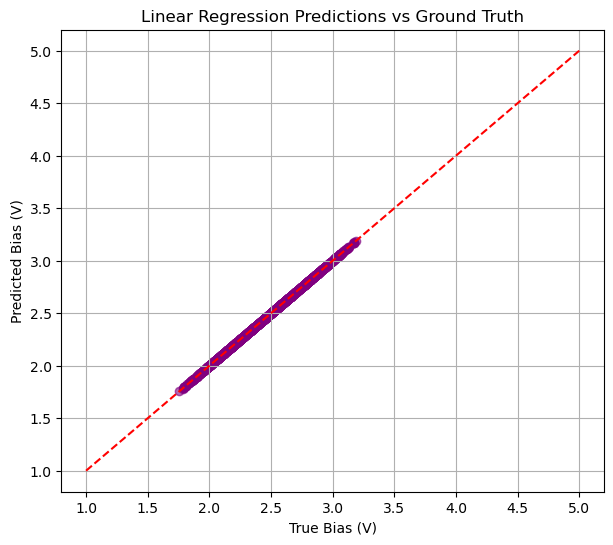

In [29]:
# ===========================================================
#   Li-Fi DCO-OFDM Bias Voltage Prediction (Leakage-Proof)
#   Comparison + Predictions + Feature Importance
# ===========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Classical ML models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Deep learning (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim

# -----------------------------------------------------------
# 1️⃣ Load Dataset
# -----------------------------------------------------------
df = pd.read_csv("lifi_ofdm_dataset_realistic_9000_sweep.csv")

# Remove the 'Bias_V' column (bias sweep) to prevent data leakage
features = ["SNR_dB", "Clip_V", "EVM_dB", "PAPR_dB", "P_rx_dBm"]
target = "Optimal_Bias_V"

X = df[features].values.astype(np.float32)
y = df[target].values.astype(np.float32)

# Normalize target for neural network training
y_scaler = MinMaxScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).flatten()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_scaled, test_size=0.2, random_state=42)

# Normalize inputs
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------------------------------------
# 2️⃣ Evaluation Function
# -----------------------------------------------------------
def evaluate_model(name, y_true, y_pred_scaled):
    # Convert scaled predictions back to original bias range
    y_pred = y_scaler.inverse_transform(np.array(y_pred_scaled).reshape(-1, 1)).flatten()
    y_true_real = y_scaler.inverse_transform(np.array(y_true).reshape(-1, 1)).flatten()
    mae = mean_absolute_error(y_true_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true_real, y_pred))
    r2 = r2_score(y_true_real, y_pred)
    print(f"\n📊 {name}")
    print(f"   Mean Absolute Error (MAE): {mae:.4f}")
    print(f"   Root Mean Square Error (RMSE): {rmse:.4f}")
    print(f"   R² Score: {r2:.4f}")
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "Predictions": y_pred, "True": y_true_real}

results = []

# -----------------------------------------------------------
# 3️⃣ Classical ML Models
# -----------------------------------------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=400, learning_rate=0.05, max_depth=5),
    "Support Vector Regressor": SVR(kernel='rbf', C=10, epsilon=0.1)
}

print("🚀 Training Classical Models...\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append(evaluate_model(name, y_test, preds))

# -----------------------------------------------------------
# 4️⃣ Deep Learning Model (MLP)
# -----------------------------------------------------------
print("\n⚙️ Training Neural Network (MLP)...\n")

class MLP(nn.Module):
    def __init__(self, d_in, hidden=(128, 64), dropout=0.1, outdim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, hidden[0]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden[0], hidden[1]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden[1], outdim)
        )
    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp = MLP(d_in=X_train.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-5)
epochs = 70

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

for epoch in range(epochs):
    mlp.train()
    optimizer.zero_grad()
    preds = mlp(X_train_t)
    loss = criterion(preds, y_train_t)
    loss.backward()
    optimizer.step()

mlp.eval()
with torch.no_grad():
    y_pred_mlp_scaled = mlp(X_test_t).cpu().numpy().flatten()

results.append(evaluate_model("Neural Network (MLP)", y_test, y_pred_mlp_scaled))

# -----------------------------------------------------------
# 5️⃣ Compare Results
# -----------------------------------------------------------
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
print("\n🏁 Final Model Comparison Summary:\n")
print(results_df[["Model", "MAE", "RMSE", "R2"]].to_string(index=False))

best_model = results_df.iloc[0]
print(f"\n🥇 Best model: {best_model['Model']}")
print(f"   R² = {best_model['R2']:.4f}, MAE = {best_model['MAE']:.4f}, RMSE = {best_model['RMSE']:.4f}")

# -----------------------------------------------------------
# 6️⃣ Show Predictions
# -----------------------------------------------------------
print("\n🔍 Predicted vs True Optimal Bias (First 10 Samples):\n")
for i in range(10):
    print(f"Sample {i+1:02d}: True = {best_model['True'][i]:.3f} V | Predicted = {best_model['Predictions'][i]:.3f} V | Error = {abs(best_model['Predictions'][i]-best_model['True'][i]):.3f} V")

# -----------------------------------------------------------
# 7️⃣ Feature Importance (Tree Models)
# -----------------------------------------------------------
print("\n📈 Feature Importance (Gradient Boosting Model):\n")

gb = models["Gradient Boosting"]
importances = gb.feature_importances_
importance_df = pd.DataFrame({"Feature": features, "Importance": importances}).sort_values(by="Importance", ascending=True)

for i, row in importance_df.iterrows():
    print(f"   {row['Feature']:<10} → {row['Importance']:.3f}")

plt.figure(figsize=(7,5))
plt.barh(importance_df["Feature"], importance_df["Importance"], color='royalblue')
plt.title("Feature Importance (Gradient Boosting Model)")
plt.xlabel("Relative Importance")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# 8️⃣ Visualization
# -----------------------------------------------------------
plt.figure(figsize=(8,5))
plt.barh(results_df["Model"], results_df["R2"], color='teal')
plt.xlabel("R² Score")
plt.title("Model Accuracy Comparison (Higher is Better)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,6))
plt.scatter(best_model["True"], best_model["Predictions"], alpha=0.6, c='purple')
plt.plot([1,5],[1,5],'r--')
plt.xlabel("True Bias (V)")
plt.ylabel("Predicted Bias (V)")
plt.title(f"{best_model['Model']} Predictions vs Ground Truth")
plt.grid(True)
plt.show()
